# 使用符號計算與數值計算分析股票價格模型

## 一、研究動機（Introduction）

在前幾次作業中，我們使用隨機模擬、bootstrap 與 MCMC 方法分析股票報酬與價格變動。本次作業進一步使用符號計算與數值計算來分析簡單的股票價格模型。

這次作業選擇指數成長模型作為股票價格模型，並利用符號計算推導其微分方程、解析解與參數敏感度，再利用數值計算代入不同參數並繪製價格變化圖。

## 二、模型設定（Model Description）

假設股票價格 $S(t)$ 隨時間變化，且其成長率與目前價格成正比：

$\frac{dS(t)}{dt} = \mu S(t)$

其中：

- $S(t)$：時間 $t$ 的股票價格
- $S_0$：初始股票價格
- $\mu$：平均成長率或報酬率
- $t$：時間

此模型的解析解為：

$S(t)=S_0 e^{\mu t}$

本研究將利用 symbolic computation 推導此結果，並利用 numerical computation 進行數值分析。

## 三、符號計算：定義模型（Symbolic Computation）

首先使用 `SymPy` 定義符號變數 $S_0$、$\mu$ 與 $t$，並建立股票價格函數：

$S(t)=S_0 e^{\mu t}$

In [1]:
import sympy as sp
import numpy as np
import matplotlib.pyplot as plt

In [6]:
# 定義符號
S0, mu, t = sp.symbols('S0 mu t', positive=True)

# 定義股票價格模型
S = S0 * sp.exp(mu * t)

S

S0*exp(mu*t)

## 四、符號計算：對時間微分

接著對 $S(t)$ 關於時間 $t$ 微分：

$\frac{dS(t)}{dt}$

此結果可用來表示股票價格的瞬時變化率。

In [7]:
dS_dt = sp.diff(S, t)

dS_dt

S0*mu*exp(mu*t)

由符號計算可得：

$\frac{dS(t)}{dt} = \mu S_0 e^{\mu t}$

由於：

$S(t)=S_0 e^{\mu t}$

因此：

$\frac{dS(t)}{dt} = \mu S(t)$

這表示價格變化率與當前價格成正比。

## 五、符號計算：解微分方程

接著從微分方程：

$\frac{dS(t)}{dt} = \mu S(t)$

出發，利用符號計算求解其一般解。

In [8]:
# 定義函數 S(t)
S_func = sp.Function('S')

# 建立微分方程
ode = sp.Eq(sp.diff(S_func(t), t), mu * S_func(t))

# 解微分方程
solution = sp.dsolve(ode)

solution

Eq(S(t), C1*exp(mu*t))

由 `SymPy` 可求得微分方程的解為：

$S(t)=C_1 e^{\mu t}$

若加入初始條件：

$S(0)=S_0$

則可得：

$S(t)=S_0 e^{\mu t}$

## 六、符號計算：參數敏感度分析

為了了解股票價格對平均報酬率 $\mu$ 的敏感度，可計算：

$\frac{\partial S(t)}{\partial \mu}$

此值表示當 $\mu$ 發生變化時，股票價格會受到多大影響。

In [9]:
dS_dmu = sp.diff(S, mu)

dS_dmu

S0*t*exp(mu*t)

符號計算結果為：

$\frac{\partial S(t)}{\partial \mu} = tS_0 e^{\mu t}$

此結果顯示，當時間 $t$ 越大時，股票價格對 $\mu$ 的敏感度越高。也就是說，在長期投資中，平均報酬率的小幅變化可能導致最終價格有明顯差異。

## 七、數值計算設定（Numerical Computation）

接著進行數值計算。設定：

- 初始股價：$S_0 = 100$
- 平均報酬率：$\mu = 0.05$
- 時間範圍：$0 \leq t \leq 5$

並計算不同時間下的股票價格。

In [10]:
# 數值參數
S0_value = 100
mu_value = 0.05

# 時間範圍
t_values = np.linspace(0, 5, 100)

# 數值計算
S_values = S0_value * np.exp(mu_value * t_values)

# 顯示第一個與最後一個價格
print("Initial price:", S_values[0])
print("Final price at t=5:", S_values[-1])

Initial price: 100.0
Final price at t=5: 128.40254166877415


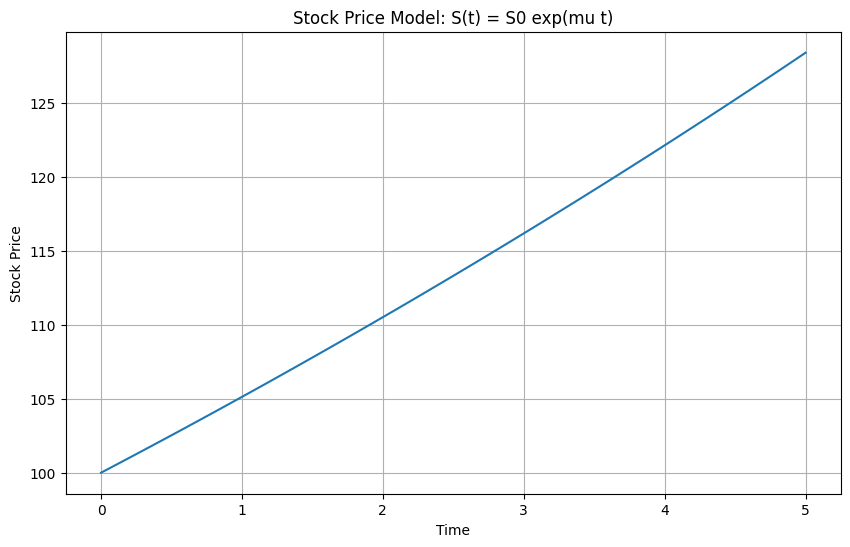

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(t_values, S_values)
plt.title("Stock Price Model: S(t) = S0 exp(mu t)")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.grid()
plt.show()

## 八、不同報酬率下的數值比較

為了觀察 $\mu$ 對股票價格的影響，本研究比較不同報酬率下的價格變化：

$\mu = 0.01,\ 0.03,\ 0.05,\ 0.08$

透過此比較，可以看出報酬率變化對長期價格的影響。

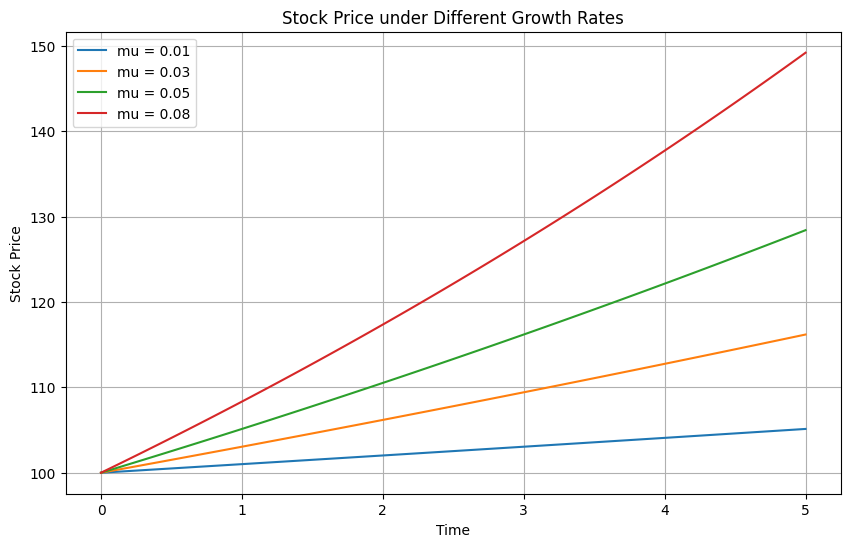

In [12]:
mu_list = [0.01, 0.03, 0.05, 0.08]

plt.figure(figsize=(10, 6))

for m in mu_list:
    S_temp = S0_value * np.exp(m * t_values)
    plt.plot(t_values, S_temp, label=f"mu = {m}")

plt.title("Stock Price under Different Growth Rates")
plt.xlabel("Time")
plt.ylabel("Stock Price")
plt.legend()
plt.grid()
plt.show()

## 九、數值敏感度分析

根據符號計算結果：

$\frac{\partial S(t)}{\partial \mu} = tS_0 e^{\mu t}$

接著將 $S_0=100$ 與 $\mu=0.05$ 代入，並觀察敏感度隨時間的變化。

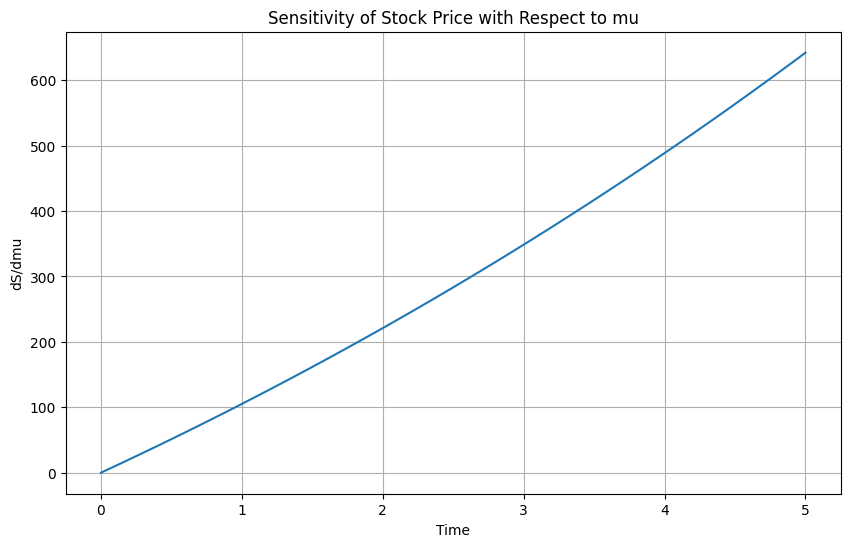

Sensitivity at t=5: 642.0127083438707


In [13]:
sensitivity_values = t_values * S0_value * np.exp(mu_value * t_values)

plt.figure(figsize=(10, 6))
plt.plot(t_values, sensitivity_values)
plt.title("Sensitivity of Stock Price with Respect to mu")
plt.xlabel("Time")
plt.ylabel("dS/dmu")
plt.grid()
plt.show()

print("Sensitivity at t=5:", sensitivity_values[-1])

## 十、結果說明（Results）

本研究利用 symbolic computation 與 numerical computation 分析股票價格模型：

$S(t)=S_0 e^{\mu t}$

其中設定：

- 初始股價：$S_0=100$
- 平均報酬率：$\mu=0.05$

數值計算結果顯示：

- 初始價格：100
- 當 $t=5$ 時，股票價格約為：

$S(5)\approx 128.40$

代表在固定成長率下，股票價格會隨時間呈現指數型成長。

---

第一張圖顯示股票價格隨時間穩定上升，且成長速度會逐漸增加。這是因為模型具有複利效果（compound growth），價格越高，後續增加的速度也越快。

---

第二張圖比較不同成長率 $\mu$ 下的股票價格變化：

$\mu = 0.01,\ 0.03,\ 0.05,\ 0.08$

結果顯示：

- 當 $\mu$ 較小時，價格成長較緩慢
- 當 $\mu$ 增加時，價格會以更快速度上升
- 在長時間下，不同 $\mu$ 所造成的價格差距會逐漸擴大

例如：

- $\mu=0.01$ 時，價格成長有限
- $\mu=0.08$ 時，價格於 $t=5$ 已接近 150

這表示報酬率對長期投資結果具有顯著影響。

---

第三張圖為敏感度分析：

$\frac{\partial S(t)}{\partial \mu} = tS_0e^{\mu t}$

此圖顯示股票價格對報酬率 $\mu$ 的敏感度會隨時間快速增加。

數值結果顯示：

$\frac{\partial S(5)}{\partial \mu} \approx 642.01$

表示當時間較長時，即使 $\mu$ 僅有小幅變化，也可能造成股票價格的明顯差異。

整體而言，本研究顯示：

1. 股票價格模型具有指數成長特性
2. 報酬率對長期價格影響非常明顯
3. 隨著時間增加，模型對參數 $\mu$ 的敏感度會快速上升
4. symbolic computation 可提供解析公式，而 numerical computation 可觀察具體數值與圖形結果

## 十一、討論（Discussion）

本研究透過 symbolic computation 與 numerical computation 分析股票價格模型。符號計算的優點是可以得到一般化的公式，例如解析解與偏導數；數值計算則可以將特定參數代入，觀察模型在不同情境下的實際表現。

從結果可知，指數成長模型雖然簡單，但可以清楚描述報酬率對股票價格的影響。特別是敏感度分析顯示，長期而言，報酬率的微小差異可能造成最終價格的明顯差距。

然而，此模型仍然相當理想化，因為它假設報酬率 $\mu$ 為固定常數，並未考慮市場隨機波動、風險或外部事件影響。

## 十二、未來研究方向（Future Work）

本研究仍可從以下方向進一步延伸：

1. **加入隨機波動項**  
   本研究使用確定性的指數成長模型，未來可加入隨機項，形成幾何布朗運動模型：

   $dS_t = \mu S_t dt + \sigma S_t dW_t$

   使模型更接近真實金融市場。

2. **估計模型參數**  
   未來可使用歷史股票資料估計 $\mu$ 與 $\sigma$，使模型具備實際應用價值。

3. **比較不同數值方法**  
   可進一步比較 Euler method、Runge-Kutta method 等數值方法在求解微分方程時的差異。

4. **加入風險分析**  
   可計算 Value at Risk（VaR）或 Expected Shortfall 等風險指標，以量化投資風險。

5. **進行多資產分析**  
   未來可將模型擴展至多支股票，並分析不同資產間的相關性。

6. **考慮時間變動報酬率**  
   可將 $\mu$ 改為隨時間變動的函數 $\mu(t)$，使模型更具彈性。

7. **結合前面作業方法**  
   可將 symbolic computation 與 bootstrap、MCMC 方法結合，用於估計參數的不確定性與可信區間。

## 十三、實驗環境（Environment）

本研究於 Jupyter Notebook 中完成，使用 Python 進行 symbolic 與 numerical computation。

使用環境如下：

- Python version: 3.14.3 (tags/v3.14.3:323c59a, Feb  3 2026, 16:04:56) [MSC v.1944 64 bit (AMD64)]
- NumPy version: 2.4.2
- Matplotlib version: 3.10.8
- SymPy version: 1.14.0
- Operating System: Windows 10

## 十四、參考文獻（References）

1. SymPy Development Team.  
   SymPy Documentation. https://docs.sympy.org/

2. NumPy Developers.  
   NumPy Documentation. https://numpy.org/doc/stable/

3. Matplotlib Development Team.  
   Matplotlib Documentation. https://matplotlib.org/stable/

4. Hull, J. C. (2018).  
   *Options, Futures, and Other Derivatives*. Pearson.

5. Ross, S. M. (2014).  
   *Introduction to Probability Models*. Academic Press.